# EDA Assignment - Cardiotocographic Dataset

## Objective
The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the **Cardiotocographic.csv** dataset.

This notebook covers:
- Data loading and basic inspection
- Data cleaning and preparation
- Missing value treatment
- Duplicate check
- Data type correction
- Outlier detection and treatment
- Statistical summary
- Histograms, boxplots, bar charts, pie chart
- Correlation heatmap
- Scatter plots, pair plot and violin plot
- Pattern recognition and insights
- Final conclusion and recommendations


## Dataset Column Meaning

The dataset contains cardiotocographic/fetal health related variables.

Common columns:

- **LB**: Baseline fetal heart rate
- **AC**: Accelerations
- **FM**: Fetal movements
- **UC**: Uterine contractions
- **DL**: Late decelerations
- **DS**: Short decelerations
- **DP**: Prolonged decelerations
- **ASTV**: Percentage of time with abnormal short-term variability
- **MSTV**: Mean value of short-term variability
- **ALTV**: Percentage of time with abnormal long-term variability
- **MLTV**: Mean value of long-term variability
- **Width**: Histogram width
- **Tendency**: Histogram tendency
- **NSP**: Fetal state class / target variable


## 1. Import Required Libraries

In [1]:
# Install required libraries if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Cardiotocographic.csv")

# Display first five rows
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
# Shape of dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2126
Number of columns: 14


In [4]:
# Display column names
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP'], dtype='object')

## 3. Basic Information About Dataset

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [6]:
# Check first few records
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [7]:
# Check last few records
df.tail()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
2121,140.0,0.000000,0.961268,0.007426,0.0,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.0,2.000000
2122,140.0,0.000775,0.000000,0.006979,0.0,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.0,2.000000
2123,140.0,0.000980,0.000000,0.006863,0.0,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.0,1.990464
2124,140.0,0.000679,0.000000,0.006110,0.0,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.0,2.000000
2125,142.0,0.001616,-0.000188,0.008078,0.0,0.0,0.0,74.0,0.4,35.857183,5.0,42.0,0.0,1.000000


## 4. Missing Value Check

Missing values can affect statistical analysis and machine learning models. So, we first check how many missing values are present in each column.


In [8]:
# Missing values count
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

LB          21
DS          21
MLTV        21
Width       21
Tendency    21
DP          21
NSP         21
AC          20
FM           0
UC           0
DL           0
ALTV         0
ASTV         0
MSTV         0
dtype: int64

In [9]:
# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
}).sort_values(by="Missing Percentage", ascending=False)

missing_report

,Missing Values,Missing Percentage
LB,21,0.987770
DS,21,0.987770
MLTV,21,0.987770
Width,21,0.987770
Tendency,21,0.987770
DP,21,0.987770
NSP,21,0.987770
AC,20,0.940734
FM,0,0.000000
UC,0,0.000000


### Missing Value Treatment

For numerical columns, missing values are filled using the **median** because median is less affected by outliers compared to mean.


In [10]:
# Fill missing values in numerical columns using median
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
df.isnull().sum()

Missing values after treatment:


LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

## 5. Duplicate Value Check

In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2


In [12]:
# Remove duplicate rows if present
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2124, 14)


## 6. Data Type Correction

Sometimes numerical values may be stored as object/string. Here, we try to convert possible columns into numeric format.


In [13]:
# Convert all possible columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

## 7. Statistical Summary

This section provides summary statistics such as count, mean, standard deviation, minimum, maximum, and quartile values.


In [14]:
# Basic statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2124.0,133.338641,11.212447,51.842487,126.000000,133.000000,140.000000,214.000000
AC,2124.0,0.003205,0.004374,-0.019284,0.000000,0.001634,0.005612,0.038567
FM,2124.0,0.009904,0.067571,-0.480634,0.000000,0.000000,0.002568,0.961268
UC,2124.0,0.004394,0.003340,-0.014925,0.001858,0.004486,0.006536,0.030002
DL,2124.0,0.001897,0.003344,-0.015393,0.000000,0.000000,0.003292,0.030769
DS,2124.0,0.000002,0.000141,-0.001353,0.000000,0.000000,0.000000,0.002706
DP,2124.0,0.000174,0.000836,-0.005348,0.000000,0.000000,0.000000,0.010695
ASTV,2124.0,47.012459,18.812403,-63.000000,32.000000,49.000000,61.000000,162.000000
MSTV,2124.0,1.364345,1.174084,-6.600000,0.700000,1.200000,1.700000,13.800000
ALTV,2124.0,10.295650,21.212676,-91.000000,0.000000,0.000000,11.000000,182.000000


### Central Tendency and Dispersion

Here we calculate:
- Mean
- Median
- Standard Deviation
- Interquartile Range (IQR)


In [15]:
summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard Deviation": df[numeric_cols].std(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75)
})

summary["IQR"] = summary["Q3"] - summary["Q1"]
summary

,Mean,Median,Standard Deviation,Q1,Q3,IQR
LB,133.338641,133.000000,11.212447,126.000000,140.000000,14.000000
AC,0.003205,0.001634,0.004374,0.000000,0.005612,0.005612
FM,0.009904,0.000000,0.067571,0.000000,0.002568,0.002568
UC,0.004394,0.004486,0.003340,0.001858,0.006536,0.004678
DL,0.001897,0.000000,0.003344,0.000000,0.003292,0.003292
DS,0.000002,0.000000,0.000141,0.000000,0.000000,0.000000
DP,0.000174,0.000000,0.000836,0.000000,0.000000,0.000000
ASTV,47.012459,49.000000,18.812403,32.000000,61.000000,29.000000
MSTV,1.364345,1.200000,1.174084,0.700000,1.700000,1.000000
ALTV,10.295650,0.000000,21.212676,0.000000,11.000000,11.000000


## 8. Outlier Detection Using IQR

Outliers are detected using the Interquartile Range method.

Formula:
- IQR = Q3 - Q1
- Lower Limit = Q1 - 1.5 × IQR
- Upper Limit = Q3 + 1.5 × IQR


In [16]:
outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    outlier_report[col] = len(outliers)

outlier_report_df = pd.DataFrame(list(outlier_report.items()), columns=["Column", "Outlier Count"])
outlier_report_df.sort_values(by="Outlier Count", ascending=False)

,Column,Outlier Count
13,NSP,559
2,FM,347
9,ALTV,318
6,DP,284
4,DL,125
5,DS,120
10,MLTV,81
8,MSTV,80
1,AC,42
3,UC,13


### Outlier Treatment

We use **IQR capping** instead of deleting rows. Capping replaces extreme values with lower or upper acceptable limits.


In [17]:
# Create a copy for outlier-treated data
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean[col] = np.where(df_clean[col] < lower_limit, lower_limit, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper_limit, upper_limit, df_clean[col])

print("Outlier capping completed.")
df_clean.head()

Outlier capping completed.


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,27.5,2.4,64.0,0.999926,1.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,20.1,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


## 9. Histograms

Histograms help us understand the distribution of numerical variables.


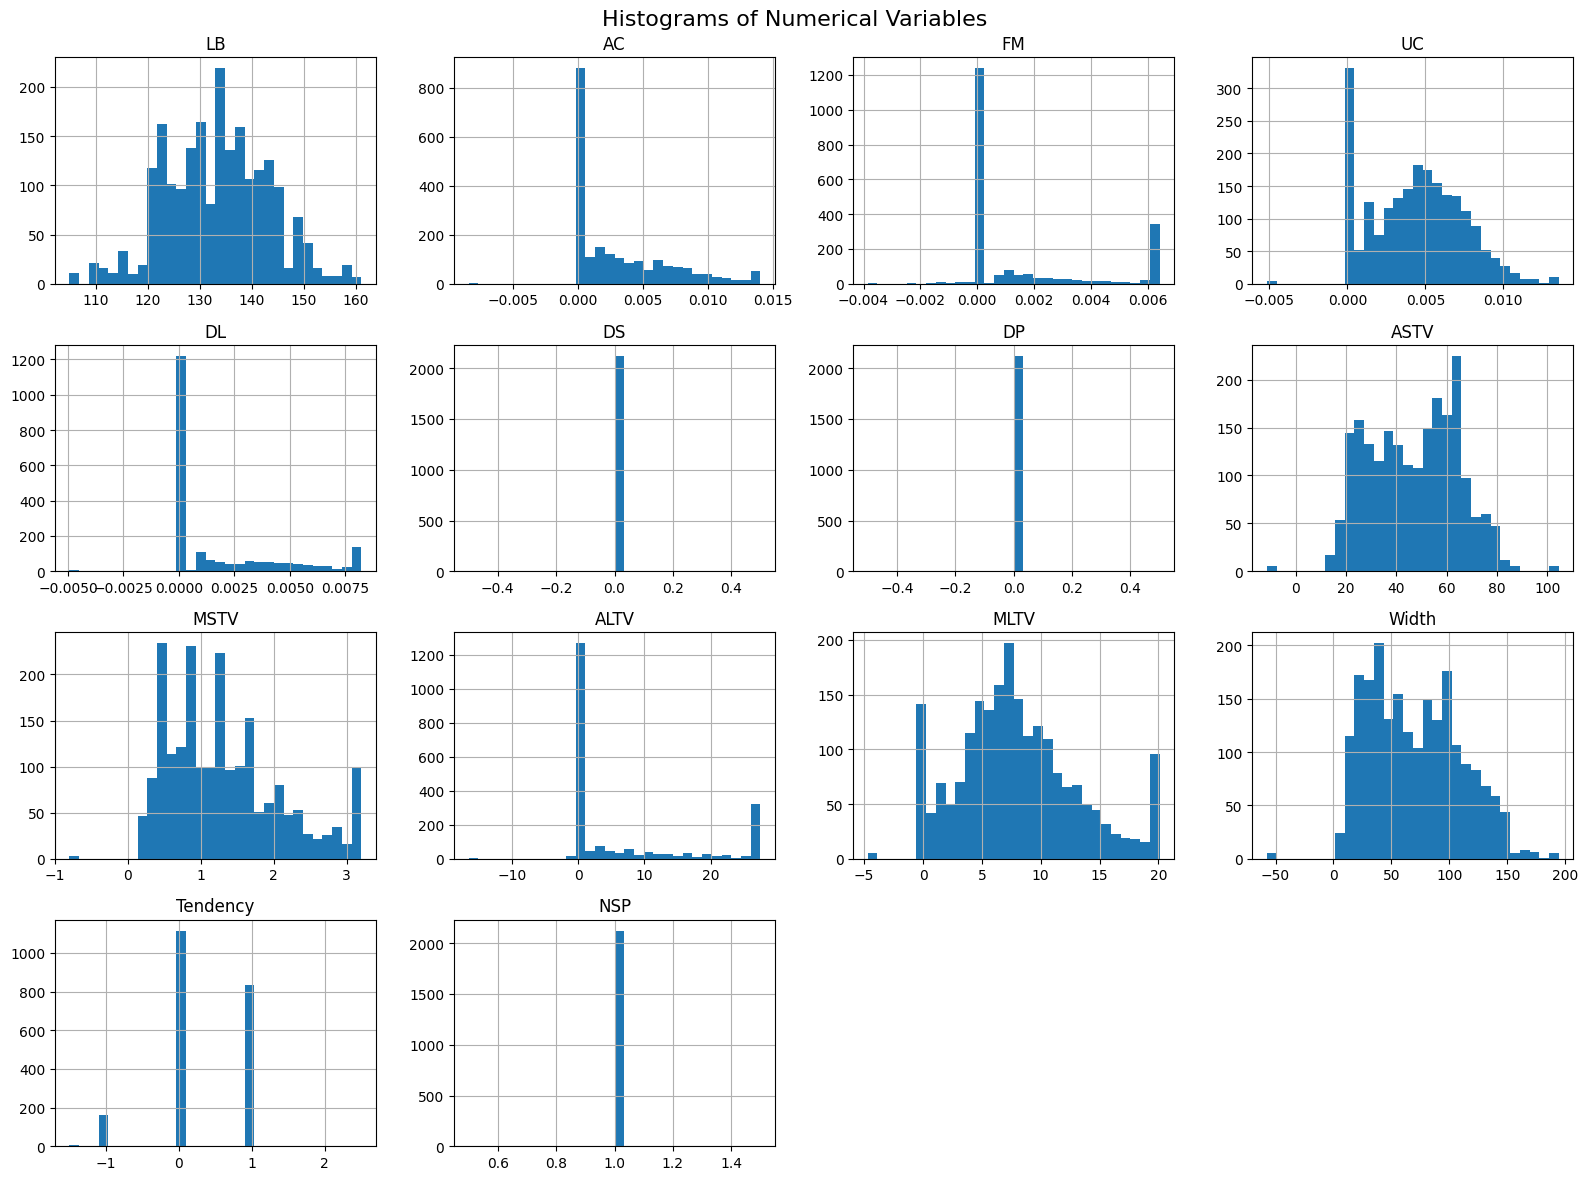

In [18]:
# Histograms for numerical columns
df_clean[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Histogram Insights

From the histograms, we can observe:
- Some variables may be normally distributed.
- Some variables may be right-skewed or left-skewed.
- Variables with many zero values indicate rare events or low-frequency medical observations.


## 10. Boxplots

Boxplots are used to visualize spread and identify outliers in numerical variables.


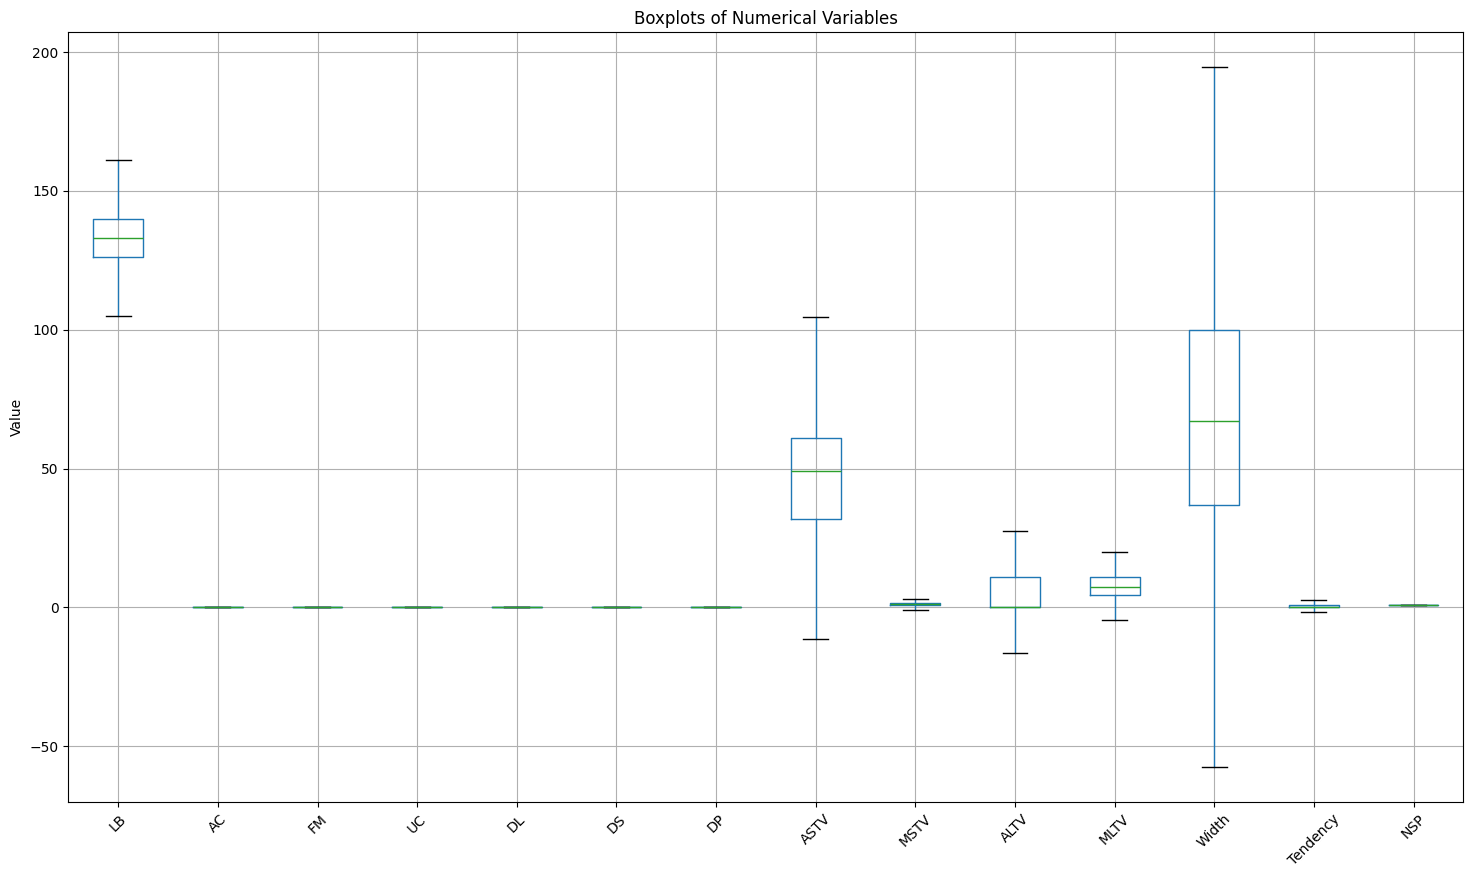

In [19]:
# Boxplots for numerical columns
plt.figure(figsize=(18, 10))
df_clean[numeric_cols].boxplot(rot=45)
plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.show()

## 11. Target Variable / Categorical Variable Analysis

In this dataset, **NSP** is generally treated as the target/category variable representing fetal state.


In [20]:
# Frequency count of NSP if available
if "NSP" in df_clean.columns:
    print(df_clean["NSP"].value_counts())
else:
    print("NSP column not found.")

NSP
1.0    2124
Name: count, dtype: int64


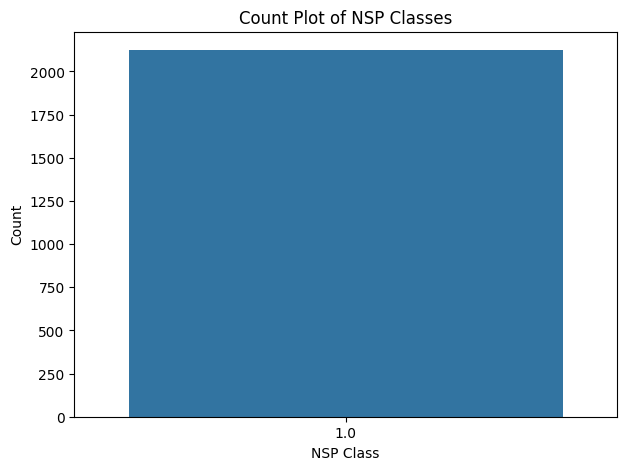

In [21]:
# Bar chart for NSP
if "NSP" in df_clean.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(x="NSP", data=df_clean)
    plt.title("Count Plot of NSP Classes")
    plt.xlabel("NSP Class")
    plt.ylabel("Count")
    plt.show()

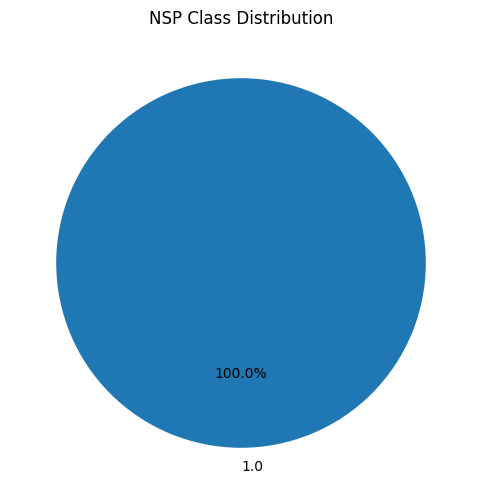

In [22]:
# Pie chart for NSP
if "NSP" in df_clean.columns:
    plt.figure(figsize=(6, 6))
    df_clean["NSP"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
    plt.title("NSP Class Distribution")
    plt.ylabel("")
    plt.show()

### NSP Distribution Insight

The NSP class distribution helps us understand whether the dataset is balanced or imbalanced. If one class has a much higher count than others, models trained on this data may become biased toward the majority class.


## 12. Correlation Analysis

Correlation helps us understand the relationship between numerical variables.


In [23]:
# Correlation matrix
corr_matrix = df_clean[numeric_cols].corr()
corr_matrix

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.081548,-0.006840,-0.163345,-0.156314,NaN,NaN,0.285464,-0.295132,0.322864,-0.042241,-0.139978,0.281144,NaN
AC,-0.081548,1.000000,0.075611,0.093222,-0.103258,NaN,NaN,-0.273189,0.216861,-0.408246,-0.151713,0.283750,0.030489,NaN
FM,-0.006840,0.075611,1.000000,-0.318156,-0.018024,NaN,NaN,0.155798,0.070412,-0.013820,-0.036439,0.164178,0.000302,NaN
UC,-0.163345,0.093222,-0.318156,1.000000,0.268151,NaN,NaN,-0.217484,0.298462,-0.294226,-0.073152,0.131010,-0.074729,NaN
DL,-0.156314,-0.103258,-0.018024,0.268151,1.000000,NaN,NaN,-0.112289,0.566625,-0.296383,-0.242345,0.514238,0.014025,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.285464,-0.273189,0.155798,-0.217484,-0.112289,NaN,NaN,1.000000,-0.433731,0.438800,-0.323930,-0.242111,-0.010237,NaN
MSTV,-0.295132,0.216861,0.070412,0.298462,0.566625,NaN,NaN,-0.433731,1.000000,-0.541296,0.010734,0.646155,-0.064696,NaN
ALTV,0.322864,-0.408246,-0.013820,-0.294226,-0.296383,NaN,NaN,0.438800,-0.541296,1.000000,-0.132584,-0.439604,0.052204,NaN


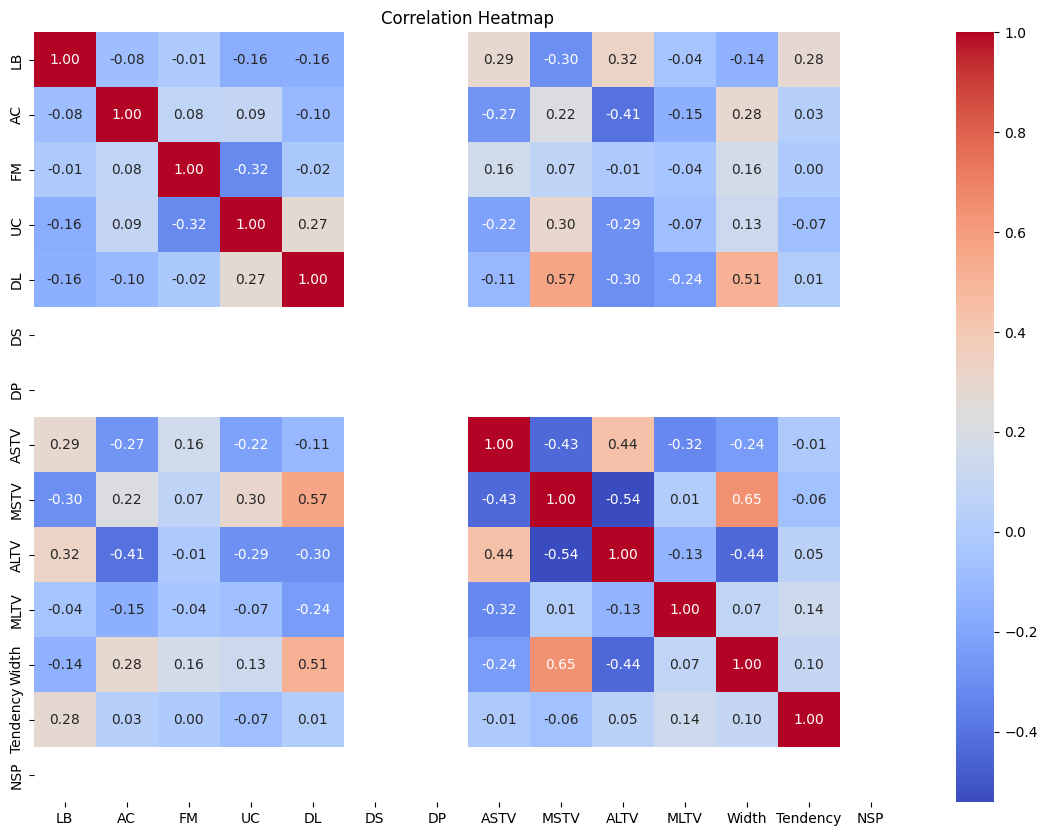

In [24]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Strong Correlation Pairs

The following code displays variable pairs having high positive or negative correlation.


In [25]:
# Find highly correlated pairs
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs["Feature 1"] != corr_pairs["Feature 2"]]

# Avoid duplicate pairs
corr_pairs["Sorted Pair"] = corr_pairs.apply(lambda x: tuple(sorted([x["Feature 1"], x["Feature 2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates("Sorted Pair").drop(columns="Sorted Pair")

# Show strong correlations
strong_corr = corr_pairs[abs(corr_pairs["Correlation"]) >= 0.5].sort_values(by="Correlation", ascending=False)
strong_corr

,Feature 1,Feature 2,Correlation
123,MSTV,Width,0.646155
64,DL,MSTV,0.566625
67,DL,Width,0.514238
121,MSTV,ALTV,-0.541296


## 13. Scatter Plot Analysis

Scatter plots help us understand the relationship between two numerical variables.


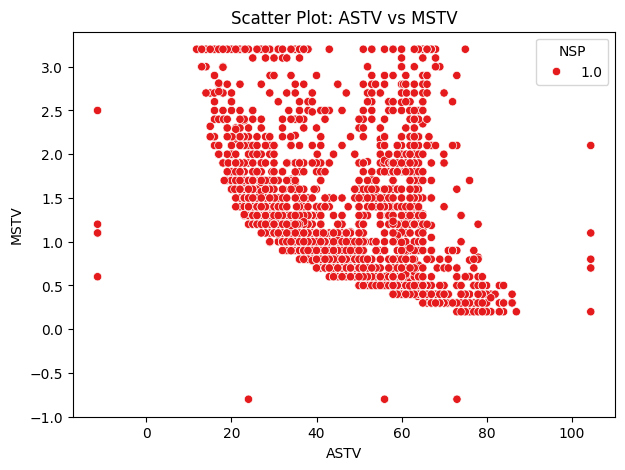

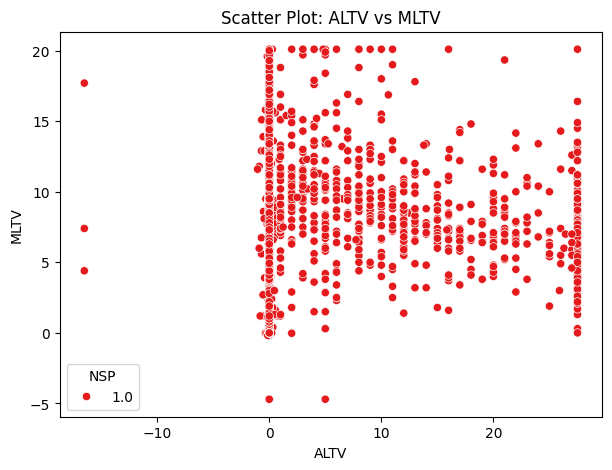

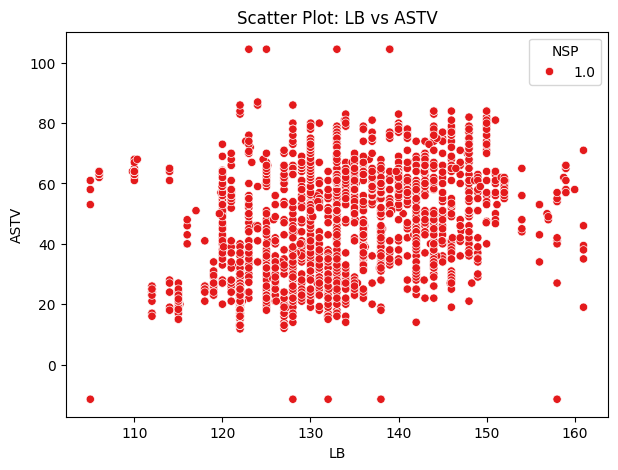

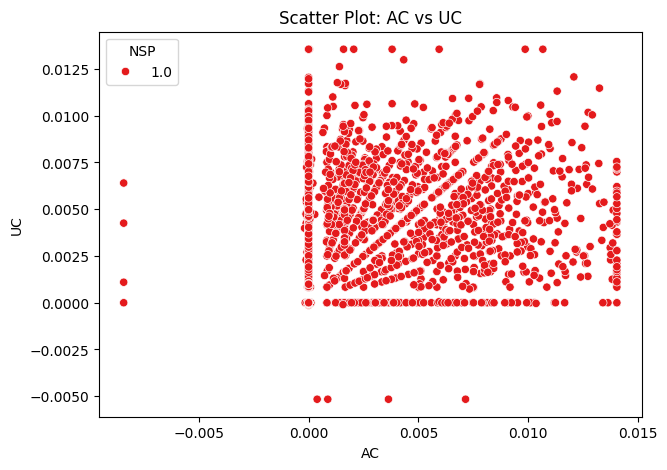

In [26]:
# Scatter plots for selected important variables
selected_pairs = [
    ("ASTV", "MSTV"),
    ("ALTV", "MLTV"),
    ("LB", "ASTV"),
    ("AC", "UC")
]

for x_col, y_col in selected_pairs:
    if x_col in df_clean.columns and y_col in df_clean.columns:
        plt.figure(figsize=(7, 5))
        if "NSP" in df_clean.columns:
            sns.scatterplot(x=x_col, y=y_col, hue="NSP", data=df_clean, palette="Set1")
        else:
            sns.scatterplot(x=x_col, y=y_col, data=df_clean)
        plt.title(f"Scatter Plot: {x_col} vs {y_col}")
        plt.show()

## 14. Pair Plot

Pair plot gives a combined view of pairwise relationships between selected variables.


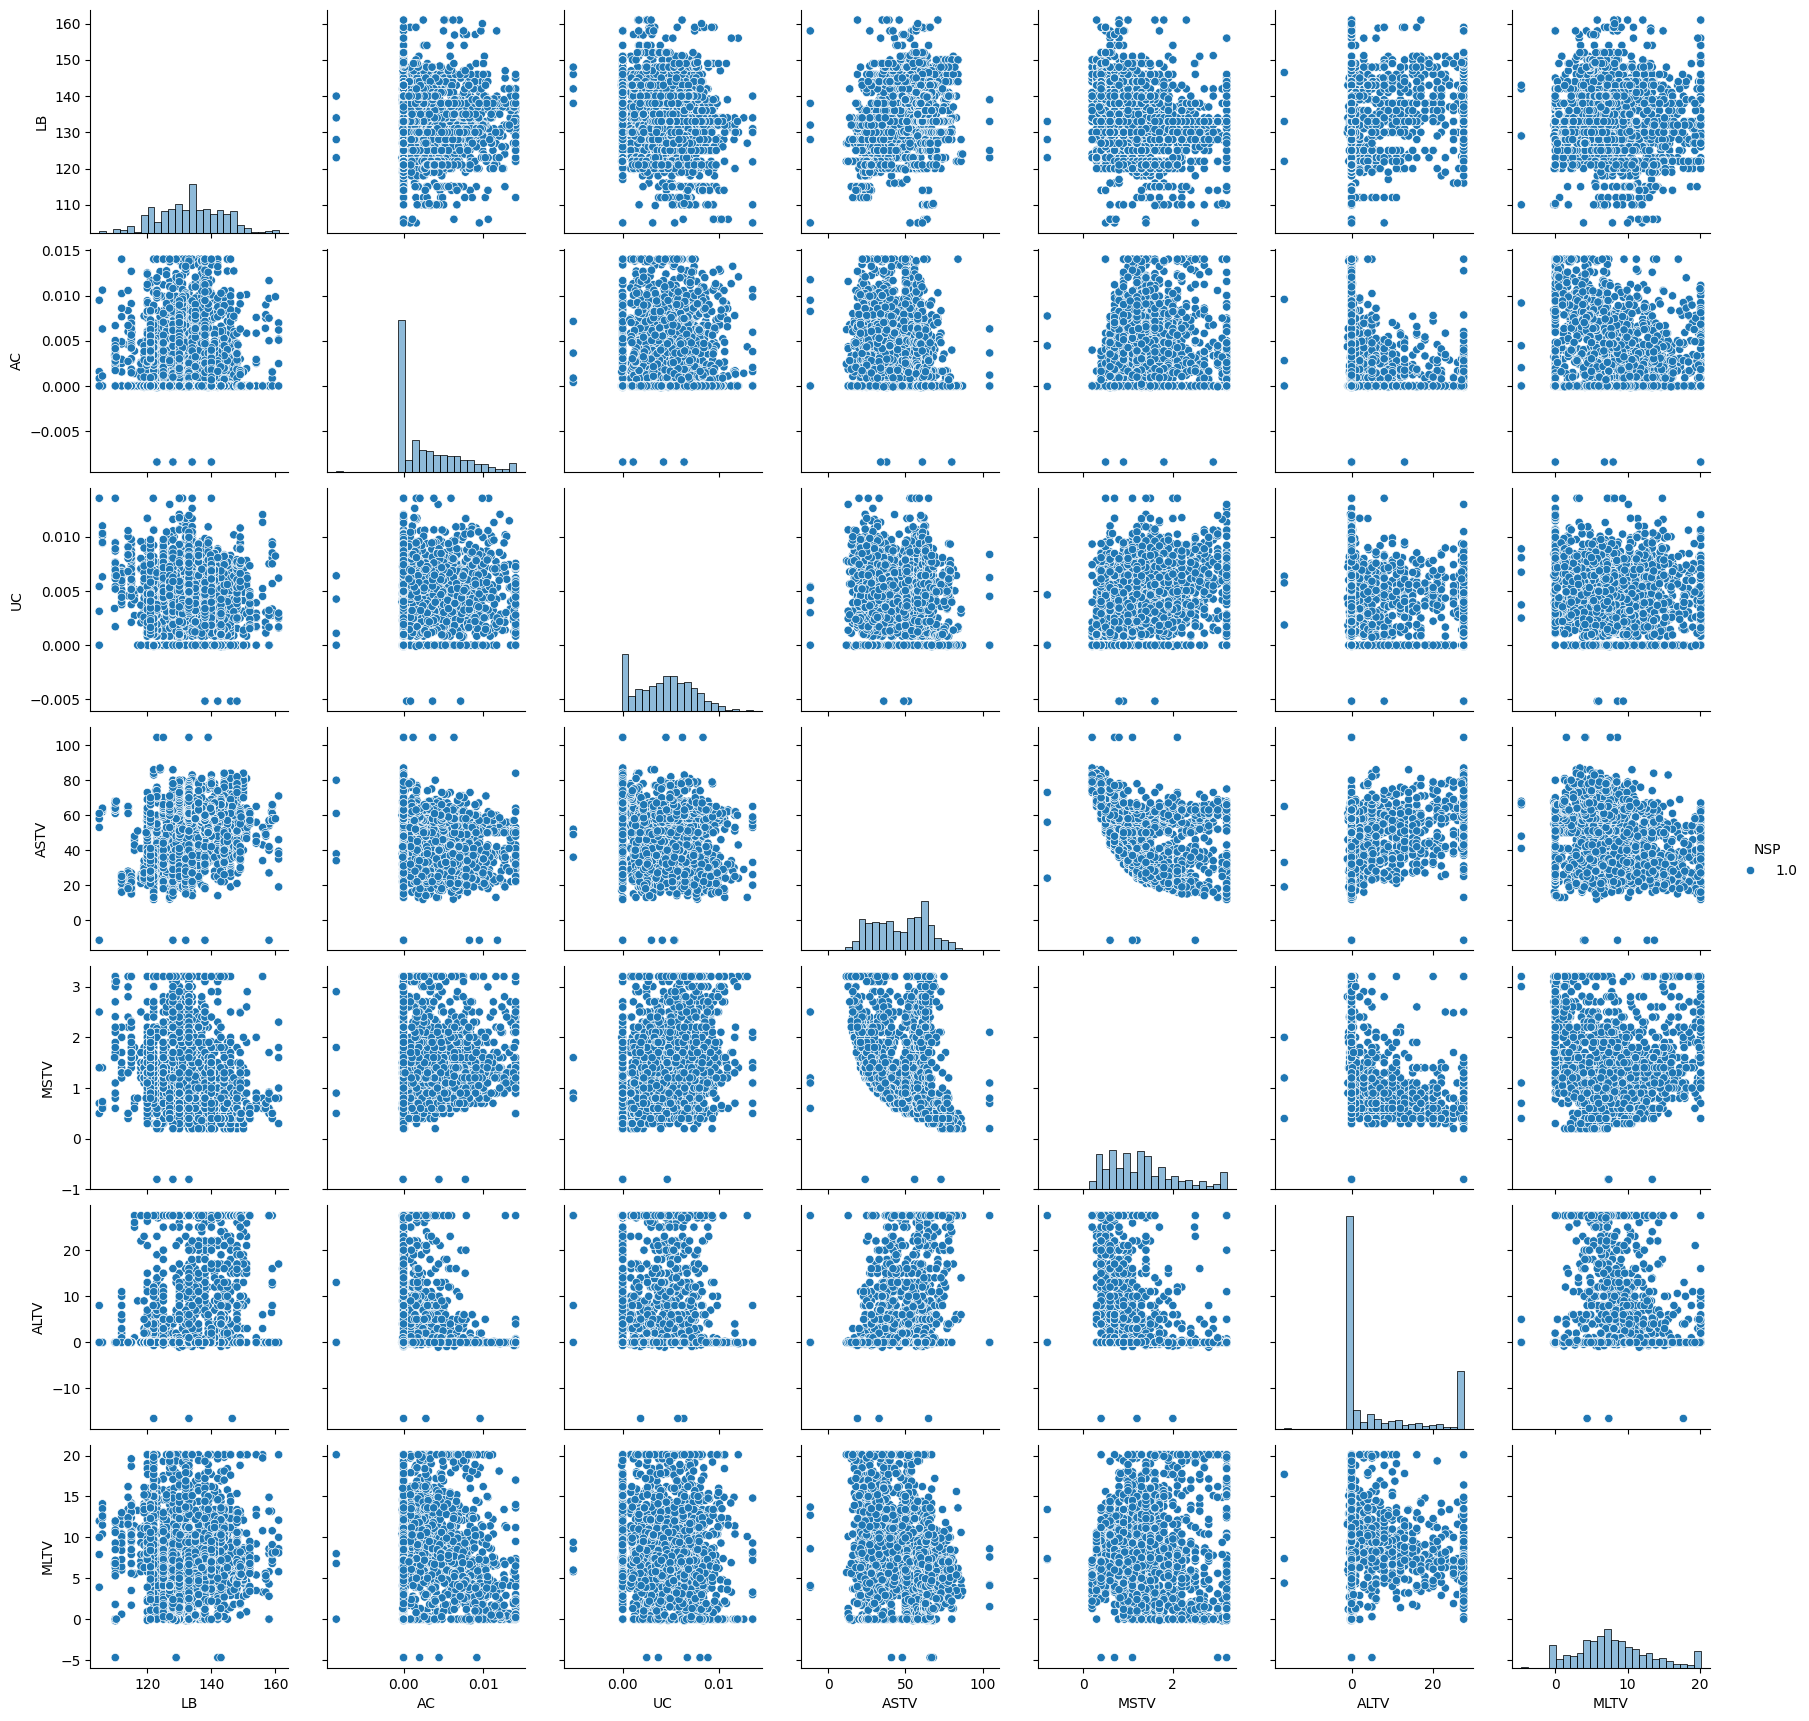

In [27]:
# Pair plot for selected columns
pair_cols = [col for col in ["LB", "AC", "UC", "ASTV", "MSTV", "ALTV", "MLTV", "NSP"] if col in df_clean.columns]

if "NSP" in pair_cols:
    sns.pairplot(df_clean[pair_cols], hue="NSP", diag_kind="hist")
else:
    sns.pairplot(df_clean[pair_cols], diag_kind="hist")

plt.show()

## 15. Violin Plot

Violin plots show the distribution of numerical variables across categories.


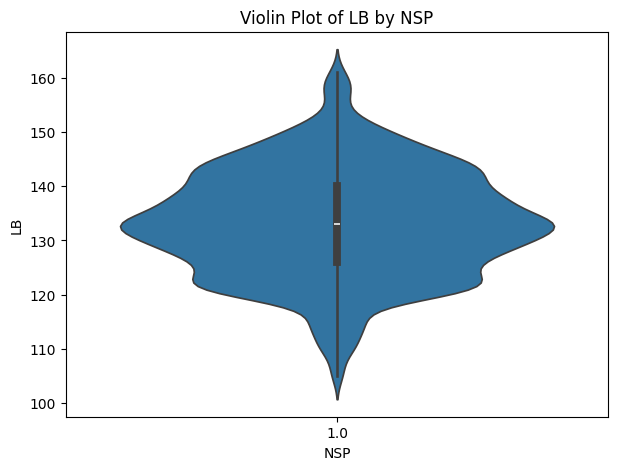

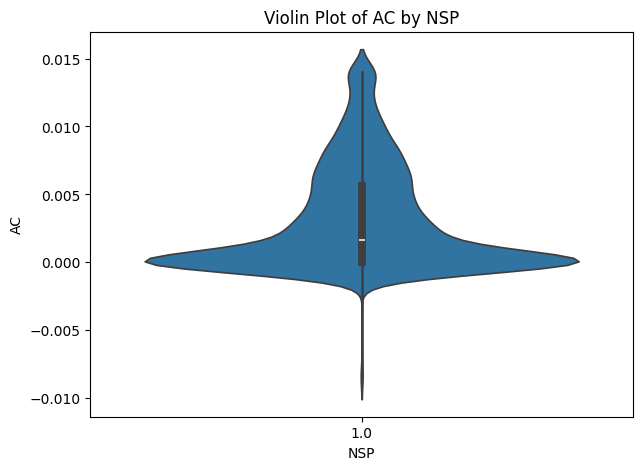

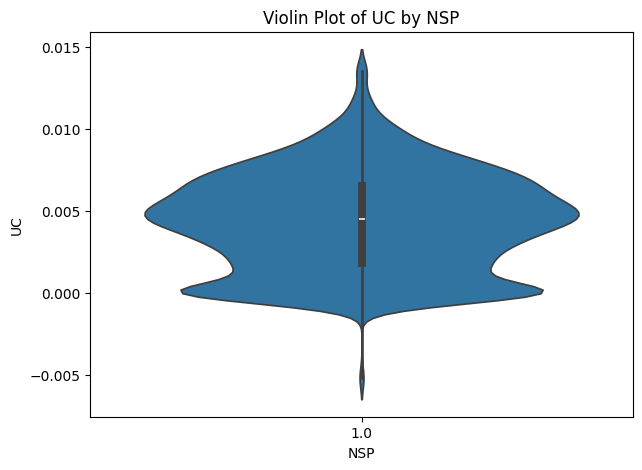

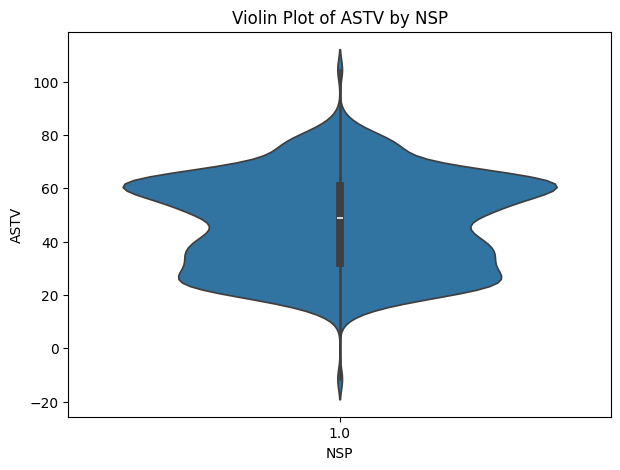

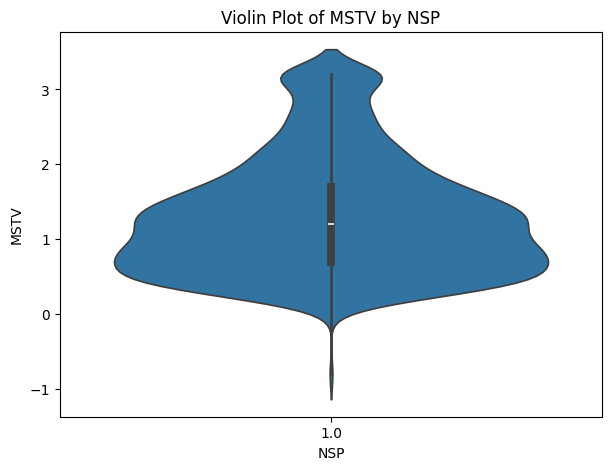

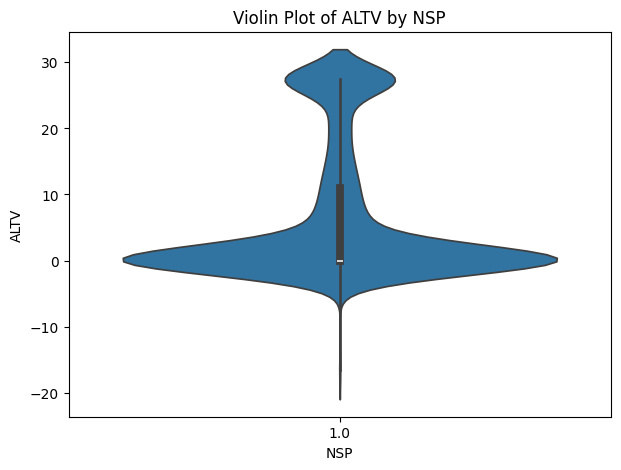

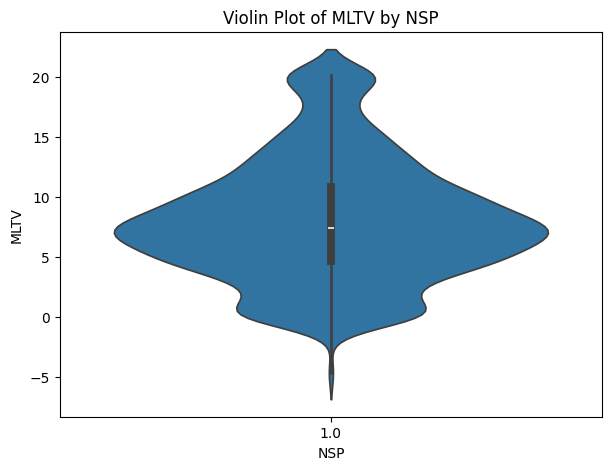

In [28]:
# Violin plots for important features against NSP
important_features = ["LB", "AC", "UC", "ASTV", "MSTV", "ALTV", "MLTV"]

if "NSP" in df_clean.columns:
    for col in important_features:
        if col in df_clean.columns:
            plt.figure(figsize=(7, 5))
            sns.violinplot(x="NSP", y=col, data=df_clean)
            plt.title(f"Violin Plot of {col} by NSP")
            plt.show()

## 16. Feature Scaling

Scaling is useful before applying many machine learning algorithms. Here we use StandardScaler.


In [29]:
# Separate target if available
if "NSP" in df_clean.columns:
    X = df_clean.drop(columns=["NSP"])
    y = df_clean["NSP"]
else:
    X = df_clean.copy()
    y = None

# Scale only numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
0,-1.338988,-0.818199,-0.631457,-1.455000,-0.663979,0.0,0.0,1.476884,-1.030002,2.004278,-1.110454,-0.159688,1.097376
1,-0.129853,0.847771,-0.631457,0.671673,0.530931,0.0,0.0,-1.703893,1.018341,-0.645351,0.475085,1.508324,-0.508991
2,-0.029092,0.049378,-0.631457,1.313738,0.580553,0.0,0.0,-1.760692,1.018341,-0.645351,1.069662,1.508324,-0.508991
3,0.071669,-0.149465,-0.631457,1.125802,0.295314,0.0,0.0,-1.760692,1.402405,-0.645351,2.397550,1.179776,1.097494
4,-0.135069,0.883044,-0.631457,1.259626,-0.663979,0.0,0.0,-1.760692,1.402405,-0.645351,2.357912,1.179776,1.097494


## 17. Pattern Recognition and Insights

Write-up for assignment:

1. **Baseline fetal heart rate (LB)** gives an idea about the average fetal heart rate.
2. **AC, FM, UC, DL, DS, DP** show fetal movement, accelerations, contractions and decelerations, which are medically important indicators.
3. **ASTV and ALTV** represent abnormal short-term and long-term variability. Higher values may indicate abnormal fetal heart rate patterns.
4. **Correlation heatmap** helps identify relationships between variables. Strong positive or negative correlations show variables that move together.
5. **NSP distribution** shows whether fetal health classes are balanced or imbalanced.
6. Some columns may contain many zero values, which means those events are rare or absent in many observations.
7. Outliers are present in medical datasets, but they should not always be deleted because they may represent important medical cases.


## 18. Final Conclusion

From this exploratory data analysis, we performed data cleaning, missing value handling, duplicate removal, outlier treatment, statistical analysis, and multiple visualizations.

### Key Findings
- The dataset contains numerical cardiotocographic features related to fetal heart rate and fetal condition.
- Missing values were handled using median imputation.
- Outliers were detected using the IQR method and treated using capping.
- Histograms and boxplots showed the distribution and spread of variables.
- Correlation heatmap helped identify relationships among variables.
- NSP class distribution helped understand the target/category balance.
- Variables such as ASTV, MSTV, ALTV, MLTV, AC, UC and LB are important for understanding fetal health patterns.

### Recommendations
- Further analysis can be done using classification models to predict NSP class.
- Class imbalance should be checked before model building.
- Medical domain validation is important before making final decisions.
- Feature scaling should be applied before distance-based or gradient-based machine learning models.


## 19. Save Cleaned Dataset

In [30]:
# Save cleaned dataset
df_clean.to_csv("Cardiotocographic_cleaned.csv", index=False)

print("Cleaned dataset saved as Cardiotocographic_cleaned.csv")

Cleaned dataset saved as Cardiotocographic_cleaned.csv
